[动态规划](./basic_algorithm/dp.md)  


动态规划就是把大问题变成小问题，并解决了小问题重复计算的方法称为动态规划  

动态规划和 DFS 区别
- 二叉树 子问题是没有交集，所以大部分二叉树都用递归或者分治法，即 DFS，就可以解决
- 像 triangle 这种是有重复走的情况，子问题是有交集，所以可以用动态规划来解决


动态规划是一种“从底至顶”的方法：从最小子问题的解开始，迭代地构建更大子问题的解，直至得到原问题的解。


#### 动态规划解题思路
求解动态规划问题该从何处入手，完整步骤是什么？
- 第一步：思考每轮的决策，定义状态，从而得到 dp表
- 第二步：找出最优子结构，进而推导出状态转移方程
- 第三步：确定边界条件和状态转移顺序

### 120. 三角形最小路径和
>给定一个三角形 triangle ，找出自顶向下的最小路径和。每一步只能移动到下一行中相邻的结点上。

思路1：dp[i,j]可由dp[i-1, j] 和dp[i-1,j-1]得出，对于首列，dp[i,0] = dp[i-1,0]。状态转移方程式cur_val + min(dp[i-1, j], dp[i-1,j-1])。正序遍历

思路2：倒序遍历。初始化dp表为最后一行元素，状态转移方程是dp[j] = triangle[i][j] + min(dp[j], dp[j+1])

In [41]:
def minimumTotal(triangle):
    n,m = len(triangle), len(triangle[-1])

    INF = 10**5
    dp = [INF]*m 
    # 初始化首行
    dp[0] = triangle[0][0]
        
    # 状态转移
    for i in range(1, n):
        leftup = dp[0]
        dp[0] += triangle[i][0]
        for j in range(1, i+1):
            temp = dp[j]
            dp[j] = min(dp[j], leftup) + triangle[i][j]
            leftup = temp
    print(*dp)

    return min(dp)
triangle = [[2],[3,4],[6,5,7],[4,1,8,3]]
# triangle = [[-1],[2,3],[1,-1,-3]]
minimumTotal(triangle)

15 11 18 16


11

In [47]:
# 倒序遍历在结构上是最优美的
def minimumTotal(triangle):
    n,m = len(triangle), len(triangle[-1])

    dp = triangle[-1].copy()
        
    # 状态转移
    for i in range(m-2, -1,-1):
        print(i)
        for j in range(len(triangle[i])):
            dp[j] = min(dp[j], dp[j+1]) + triangle[i][j]
    print(*dp)

    return dp[0]
triangle = [[2],[3,4],[6,5,7],[4,1,8,3]]
# triangle = [[-1],[2,3],[1,-1,-3]]
minimumTotal(triangle)

2
1
0
11 10 10 3


11

### 常见四种类型 （有四种常见的DP模版）
- 1、Matrix DP (10%)
- 2、Sequence (40%)
- 3、Two Sequences DP (40%)
- 4、Backpack (10%)
> note:
> - 贪心算法大多题目靠背答案，所以如果能用动态规划就尽量用动规，不用贪心算法


## 1、矩阵类型 (10%) 
在这种题中，dp表初始化为何矩阵大小一样就好了，在逐步求解的过程中，就是通过就局部min逐渐减少可能得路径，等走到终点，唯一的最小路径和也出来了，triangle也属于矩阵 DP
- 做题技巧：行扫描，dp表的大小是矩阵的列数 dp = [0]*len(matrix[0])


### 64. 最小路径和
>给定一个包含非负整数的  m x n  网格，请找出一条从左上角到右下角的路径，使得路径上的数字总和为最小。

思路：这个用动态规划做可以做空间优化变成一维dp。在正序遍历和倒序遍历都可以的情况下，写倒序遍历。锻炼自己的dp思维能力。写成正序吧

In [56]:
def minPathSum(grid):
    n,m = len(grid),len(grid[0])
    # dp 表
    dp = grid[0].copy()

    # 初始化
    for j in range(1,m):
        dp[j] = dp[j] + dp[j-1]
    # 状态转移
    
    for i in range(1,n):
        dp[0] += grid[i][0]
        for j in range(1,m):
            dp[j] = min(dp[j],dp[j-1]) + grid[i][j]
            
    print(dp)    
    return dp[-1]
    
grid = [[1,3,1],[1,5,1],[4,2,1]]
minPathSum(grid)

[6, 8, 7]


7

### 62. 不同路径
>一个机器人位于一个 m x n 网格的左上角 （起始点在下图中标记为“Start” ）。 机器人每次只能向下或者向右移动一步。机器人试图达到网格的右下角（在下图中标记为“Finish”）。 问总共有多少条不同的路径？

思路：如下图, 最优子结构：dp[i,j]的不同路径是dp[i,j-1] 加上 dp[i-1]。首行首列全都初始化为1. 



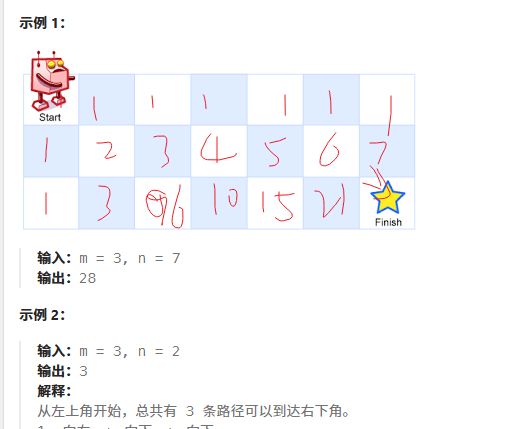

In [ ]:
def uniquePath(m,n):
    dp = [1]*n
    for _ in range(1,m):
        for j in range(1,n):
            dp[j] += dp[j-1]
    print(dp)
    return dp[-1]
uniquePath(3,3)

[1, 3, 6]


6

### 63. 不同路径 II
>这题是在62题的基础上加上了障碍点。

思路：预见障碍怎么办，该点变为0 。注意：障碍也可以出现在起始点。首行初始化有点特殊，遇到障碍的点后面应该全是0。首列也是这样处理

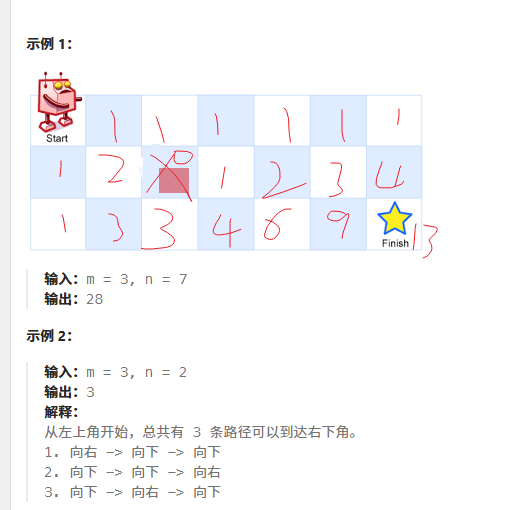  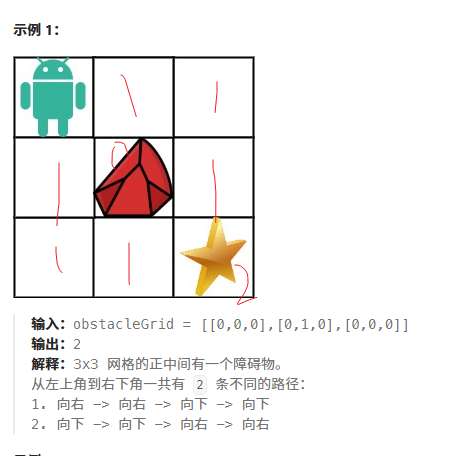  

In [ ]:
def uniquePathsWithObstacles(obstacleGrid):
    if obstacleGrid[0][0]:
        return 0
    m,n = len(obstacleGrid),len(obstacleGrid[0])
    # dp 表
    dp = [1]*n
    # 状态初始化
    for j in range(1,n):
        if obstacleGrid[0][j]:
            break
    else:
        j = -1   # 循环没遇到 break（说明没找到,Python 独有）
    if j != -1:
        # 切片是浅拷贝
        dp[j:] = [0]*(n-j)
    # 状态转移
    for i in range(1,m):
        if obstacleGrid[i][0]:
            dp[0] = 0
        for j in range(1,n):
            if obstacleGrid[i][j]:
                dp[j] = 0
            else :
                dp[j] += dp[j-1]

    print(dp)
    return dp[-1]
obstacleGrid = [[0,0,0],[0,1,0],[0,0,0]]
uniquePathsWithObstacles(obstacleGrid)

## 2、序列类型（40%）

最经典的题是爬楼梯

### 70. 爬楼梯
>假设你正在爬楼梯。需要  n  阶你才能到达楼顶。每次你可以爬 1 或 2 个台阶。你有多少种不同的方法可以爬到楼顶呢？

思路：
- dp表：dp = [1,1]，空间优化后的。
- 最优子结构：dp[i]是dp[i-1] 和 dp[i-2]的和。空间优化后，dp表更新是将后一个新的是dp[0]、dp[1]的和，存到dp[1]上，dp[1]覆盖到dp[0]上，最后结果是dp[1]。

可以看到从第三层楼梯开始，第三层楼梯可以有1和个2层来，那么就是他们的方案数相加，这个矩阵问题有点类似，当前解的来源，子解集的大小，那么当爬楼梯的人，从1,2步，变为了1,2,3步, 这种问题也好解决了

序列问题，内存特别省，简单问题一次正向遍历就够了

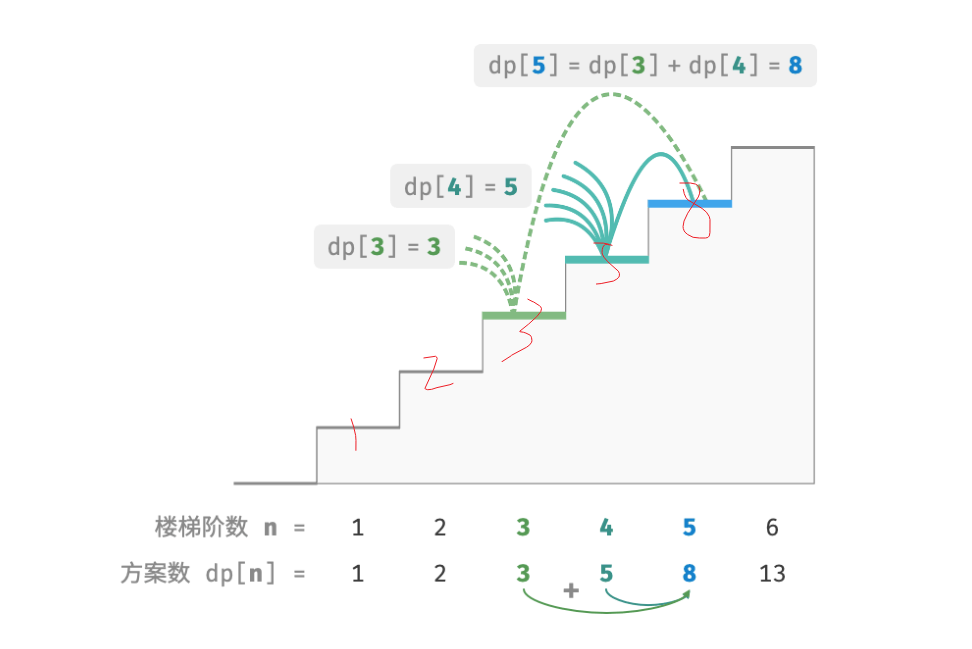

In [92]:
def climbStairs(n):
    if n in [1,2]:
        return n
    dp = [1,1]
    for i in range(2,n+1):
       dp[0], dp[1] =  dp[1],dp[0]+dp[1]
    print(dp)
    return dp[-1]
climbStairs(4)

[3, 5]


5

### 55. 跳跃游戏
>给定一个非负整数数组，你最初位于数组的第一个位置。 数组中的每个元素代表你在该位置可以跳跃的最大长度。 判断你是否能够到达最后一个位置。

解法：直接DP无法得到O(n)的解，考虑间接DP

In [ ]:
curr_max = 5
y = 8
# 1
if curr_max-1 < y:
    curr_max= y
else:
    curr_max = curr_max-1
# 2
curr_max= y if curr_max-1 < y  else curr_max-1

# 3
curr_max = max(curr_max-1,y)

# 结论：python内置的max(),底层是c语言实现的，所以无论从效率还是可读性，max() 可以放心用

8

In [29]:
nums = [9,4,5,5,7,9]
idx, val = max(enumerate(nums), key=lambda x: (x[1], x[0]))
idx, val 

(5, 9)

In [ ]:
# 思路：问题分解后，能否到达最后一个变成了能否到达i-1个，进而编程，i,i-1,i-2,3,2,1
# 从head 到 tail
def canJump(nums):
    # dp表每个状态对应的解，这里max_pos,不是，所以叫做间接DP
    max_pos = nums[0]
    for i in range(1,len(nums)):
        if max_pos < 1:
            return False
        max_pos = max(max_pos-1,nums[i])
    return True

# 加约束：最小跳跃次数
# 思路：我们现在从到达每个位置需要的最小跳跃次数 转换为 当前跳跃次数可以到达的最远距离。
def jump(nums):
    # 贪心比较好
    cur_max = 0
    step_max = 0
    step = 0

    for i in range(len(nums)):
        if cur_max < i:
            return float('inf')
        if step_max < i:  # can't reach i in current number of steps
            step += 1
            step_max = cur_max
        cur_max = max(cur_max, i + nums[i]) # DP
        print(step)
    return step

    
nums = [2,3,1,1,4]
# nums = [2,3,1]
# canJump(nums)
jump(nums)


0
1
1
2
2


2

In [ ]:
# palindrome
def minCut(s):
    N = len(s)
    # 目标DP
    dp_min = [0] * N
    # 回文DP
    dp_pal = [True] * N
    def ifPalindrome(i,j):
        # 回文DP 设计的真好
        dp_pal[i] = (s[i] == s[j] and dp_pal[i+1])
        return dp_pal[i]
    for j in range(1,N):
        min_cut = dp_min[j-1] + 1
        if ifPalindrome(0, j):
            min_cut = 0
        for i in range(1, j):
            if ifPalindrome(i, j):
                min_cut = min(min_cut, dp_min[i - 1] + 1)
        
        dp_min[j] = min_cut
                
    
    return dp_min[-1]
s= "aab"
minCut(s)

1

bisect.bisect_left(nums, x)  
在已排序的列表 nums 中，找到值 x 应该插入的位置（保持排序）。
- 如果 x 已经存在，返回它 最左边 的下标；
- 如果 x 不存在，返回它应该插入的位置下标；
- 不会修改原列表，只返回下标。

In [46]:
import bisect
def lengthOfLIS(nums):
    seq = [nums[0]]
    for i in range(1, len(nums)):
        idx = bisect.bisect_left(seq, nums[i])
        if idx == len(seq):  # 插入位置不是最后一个，说明
            seq.append(nums[i])
        else:
            seq[idx] = nums[i]

    print(seq)
    return len(seq)
    
nums = [10,9,2,5,3,7,101,18]
lengthOfLIS(nums)

[2, 3, 7, 18]


4

In [6]:
dp = [False]*(5+1)

In [8]:
def workBreak(s, wordDict):
    # 有的dp表是不能做空间优化的
    N = len(s)
    dp = [False]*(N+1)
    dp[-1] = True
    for j in range(N):
        for i in range(j+1):
            if dp[i-1] and s[i:j+1] in wordDict:
                dp[j] = True
                break
    return dp[-2]
        
    # in wordDict
s = "leetcode"
wordDict = ["leet", "code"]
workBreak(s, wordDict)

True

### 3、Two Sequences DP（40%）

In [9]:
int(True)

1

In [14]:
def longestCommonSubsequence(text1,text2):
    
    if len(text1) < len(text2):
        text1,text2 = text2,text1
    M,N =len(text1), len(text2) 
    dp = [int(text1[0]==text2[0])] * N   # previous row
    dp_new = [0] * N                     # current row
    for j in range(1,N):
        dp[j] = 1 if text2[j] == text1[0] else dp[j-1]
    
    for i in range(1,M):
        dp_new[0] = 1 if dp[0]==1 or text2[0] == text1[i] else 0
        for j in range(1,N):
            if text2[j] != text1[i]:
                dp_new[j] = max(dp[j], dp_new[j - 1])
            else:
                dp_new[j] = dp[j-1] + 1
        
        dp,dp_new = dp_new,dp
    return dp[-1]
    
    
text1 = "abcde"
text2 = "bace" 
longestCommonSubsequence(text1,text2)

3

In [18]:

def minDistance( word1, word2):
    if len(word1) < len(word2):
        word1,word2 = word2,word1
    M, N = len(word1), len(word2)
    dp = [int(word1[0] != word2[0])]*N             # 先前的行
    dp_new = [0]*N         # 当前的行
    for j in range(1,N):
        dp[j] = dp[j-1] + int(word2[j] != word1[0] or dp[j-1] != j)
    print("初始状态dp表：",dp)
    for i in range(1, M):
        dp_new[0] = dp[0] + int(word2[0] != word1[i] or dp[0] != i)
        for j in range(1,N):
            # 删除、插入、替换
            dp_new[j] = min(dp[j-1] + int(word2[j] != word1[i]), dp[j] + 1, dp_new[j-1] + 1 ) 
        dp,dp_new = dp_new,dp
        
    return dp[-1]
    
word1 = "horse"
word2 = "ros"
minDistance( word1, word2)

初始状态dp表： [1, 2, 3]


3

### 4、零钱和背包（10%）

零钱兑换可以看作完全背包问题的一种特殊情况

In [23]:
def coinChange(coins, amount):
    M,N = len(coins)+1, amount+1
    dp = [float('inf')]*N
    dp[0] = 0 
    # 状态转移
    for i in range(1,M):
        # 逐个去填
        for j in range(1,N):
            real_idx = j -coins[i-1]
            if real_idx < 0:
                dp[j] = dp[j]
            else:
                dp[j] = min(dp[j], dp[real_idx]+1)
    return dp[-1] if dp[-1] != float('inf') else -1
coins = [1, 2, 5]
amount = 11
coinChange(coins, amount)

3

### 0-1背包问题
物品编号为i  
背包容量为c, 状态[i,c]对应的子问题是：前i个物品在容量为c的背包中的最大价值   
待求解的是dp[n,cap], 因此DP表的大小是（n+1）x（cap+1）


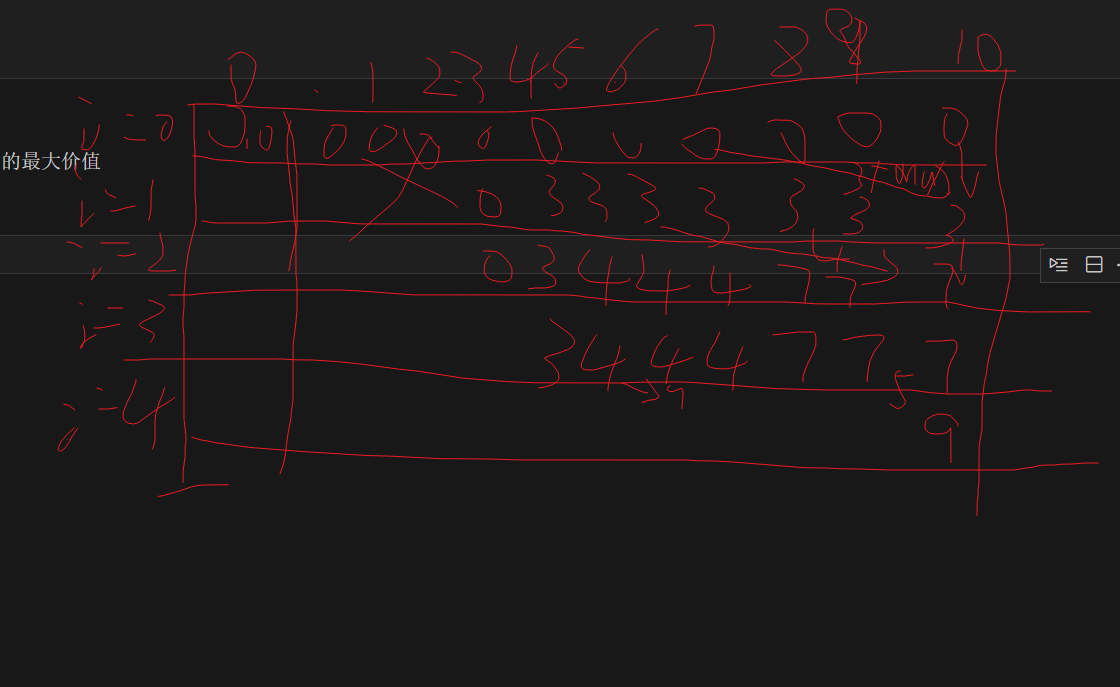

In [28]:
# 0-1
def back_pack(m,a):
    # 初始化DP表
    dp = [0]*(m+1)
    # 状态转移
    for i in range(1,len(a)+1):
        # 倒序遍历
        for c in range(m,0,-1):
            # c:10,9,8,7,6...1
            # i-1 = 0
            if a[i-1] > c:
                # 若超过背包容量，则不选物品i
                dp[c] = dp[c]
            else:
                # 不选和选物品 i 这两种方案的较大值
                dp[c] = max(dp[c], dp[c - a[i - 1]] + a[i - 1])
            
    return dp[m]
a = [3,4,8,5]
m= 10
back_pack(m,a)

9

In [25]:
for c in range(10,0,-1):
    print(c)

10
9
8
7
6
5
4
3
2
1
